# Centralidades de Hubs y Autoridad

Se genera una red de las 30 empresas con mayor capitalizacion de mercado que cotizan en el S&P500.

- Nodos: 30 tickers con mayor market cap del S&P 500.
- Aristas dirigidas: $u\to v$ significa “$u$ provee a $v$”.


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import plotly.graph_objects as go
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display
import matplotlib
from matplotlib import colors as mcolors

pio.renderers.default = "vscode"
plt.set_cmap("rainbow")

<Figure size 640x480 with 0 Axes>

In [2]:
from typing import List, Tuple

V: List[str] = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "GOOG", "AVGO", "META", "TSLA", "BRK.B",
    "JPM", "V", "MA", "WMT", "COST", "ORCL", "LLY", "XOM", "JNJ", "PLTR",
    "BAC", "ABBV", "MU", "HD", "NFLX", "AMD", "PG", "GE", "CVX", "UNH"
]

E: List[Tuple[str, str]] = [
    # semiconductores / hardware / computo
    ("MU", "NVDA"),
    ("AVGO", "AAPL"),

    ("NVDA", "MSFT"), ("NVDA", "AMZN"), ("NVDA", "GOOG"), ("NVDA", "GOOGL"),
    ("NVDA", "ORCL"), ("NVDA", "META"), ("NVDA", "TSLA"),

    ("AMD", "AMZN"), ("AMD", "MSFT"), ("AMD", "ORCL"), ("AMD", "TSLA"),

    # nube / servicios
    ("AMZN", "NFLX"),
    ("AMZN", "XOM"), ("AMZN", "JNJ"), ("AMZN", "ABBV"),
    ("AMZN", "PLTR"),

    ("MSFT", "CVX"), ("MSFT", "GE"), ("MSFT", "UNH"),
    ("MSFT", "PLTR"),

    ("GOOGL", "PLTR"),
    ("ORCL", "PLTR"),

    # retail
    ("AAPL", "WMT"), ("AAPL", "COST"),
    ("PG", "WMT"),
    ("BRK.B", "WMT"),

    # pagos / tarjetas
    ("V", "COST"), ("V", "HD"), ("V", "BAC"),
    ("MA", "HD"), ("MA", "WMT"), ("MA", "AAPL"), ("MA", "BAC"),
    ("JPM", "AAPL"),

    # farmacia
    ("LLY", "AMZN"),
]

In [3]:
G1 = nx.DiGraph()
G1.add_nodes_from(V)
G1.add_edges_from(E)

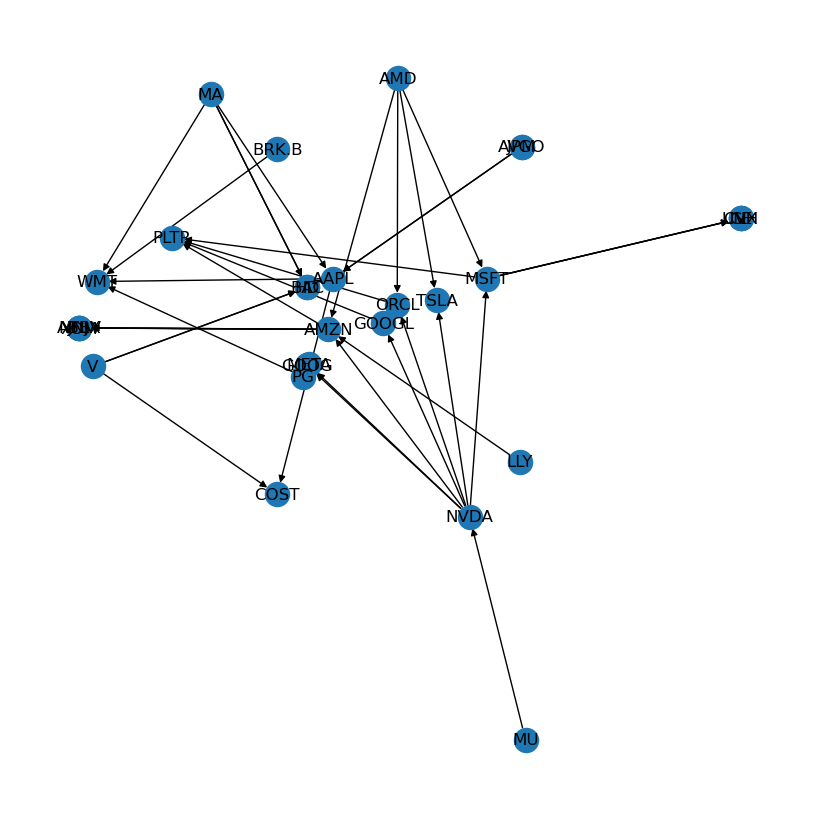

In [4]:
plt.figure(figsize=[8, 8])
layout = nx.kamada_kawai_layout(G1)
nx.draw(G1, layout, with_labels=True)

# Actividad


In [5]:
def safe_katz_centrality(G, alpha=0.5, step=0.01):
    while alpha > 0:
        try:
            return nx.katz_centrality(G, alpha=alpha), alpha
        except Exception:
            alpha -= step

    raise ValueError("Katz centrality did not converge for any positive alpha.")

deg_centralidades = nx.degree_centrality(G1)
eig_centralidades = nx.eigenvector_centrality(G1, tol=0.0001)
katz_centralidades, katz_alpha = safe_katz_centrality(G1, alpha=0.1)
print(f"Convergio con un alpha={katz_alpha:.4f}")
pg_centralidades = nx.pagerank(G1)
hubs_centralidades, auth_centralidades = nx.hits(G1)
clos_centralidades = nx.closeness_centrality(G1)
btw_centralidades = nx.betweenness_centrality(G1)


def sum1_dict(d):
    s = sum(abs(v) for v in d.values())
    return {k: (v / s if s != 0 else 0.0) for k, v in d.items()}


deg_centralidades = sum1_dict(deg_centralidades)
eig_centralidades = sum1_dict(eig_centralidades)
katz_centralidades = sum1_dict(katz_centralidades)
pg_centralidades = sum1_dict(pg_centralidades)
hubs_centralidades = sum1_dict(hubs_centralidades)
auth_centralidades = sum1_dict(auth_centralidades)
clos_centralidades = sum1_dict(clos_centralidades)
btw_centralidades = sum1_dict(btw_centralidades)

eig_sizes = np.array([eig_centralidades[n] for n in G1])
deg_colors = np.array([deg_centralidades[i] for i in G1])
pg_sizes = np.array([pg_centralidades[n] for n in G1])
katz_colors = np.array([katz_centralidades[i] for i in G1])
hubs_colors = np.array([hubs_centralidades[i] for i in G1])
auth_colors = np.array([auth_centralidades[i] for i in G1])
clos_colors = np.array([clos_centralidades[i] for i in G1])
btw_colors = np.array([btw_centralidades[i] for i in G1])

metrics = {
    "Degree": np.asarray(deg_colors, dtype=float),
    "Eigenvector": np.asarray(eig_sizes, dtype=float),
    "Katz": np.asarray(katz_colors, dtype=float),
    "PageRank": np.asarray(pg_sizes, dtype=float),
    "Hubs": np.asarray(hubs_colors, dtype=float),
    "Authorities": np.asarray(auth_colors, dtype=float),
    "Closeness": np.asarray(clos_colors, dtype=float),
    "Betweenness": np.asarray(btw_colors, dtype=float),
}

# if is directed, we can also calculate in-degree centrality
if G1.is_directed():
    deg_in_centralidades = nx.in_degree_centrality(G1)
    deg_out_centralidades = nx.out_degree_centrality(G1)
    deg_in_centralidades = sum1_dict(deg_in_centralidades)
    deg_out_centralidades = sum1_dict(deg_out_centralidades)
    deg_in_colors = np.array([deg_in_centralidades[i] for i in G1])
    deg_out_colors = np.array([deg_out_centralidades[i] for i in G1])
    metrics["InDegree"] = np.asarray(deg_in_colors, dtype=float)
    metrics["OutDegree"] = np.asarray(deg_out_colors, dtype=float)

Convergio con un alpha=0.1000


In [6]:
k = 10

top_deg = [n for n, v in sorted(
    deg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_eig = [n for n, v in sorted(
    eig_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_katz = [n for n, v in sorted(
    katz_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_pg = [n for n, v in sorted(
    pg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_hubs = [n for n, v in sorted(
    hubs_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_auth = [n for n, v in sorted(
    auth_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_clos = [n for n, v in sorted(
    clos_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_btw = [n for n, v in sorted(
    btw_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]

if G1.is_directed():
    top_deg_in = [n for n, v in sorted(
        deg_in_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
    top_deg_out = [n for n, v in sorted(
        deg_out_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]

In [7]:
def plot_network(
    G,
    metrics,
    metric="Degree",
    topk=10,
    largest_first=True,
    layout="kamada_kawai",
    colorscale="Turbo",
    renderer="vscode",   # or "notebook_connected"
    interactive=False,   # default static
):
    nodes = list(G.nodes())
    N = len(nodes)

    # Validate and normalize metrics
    m = {}
    for name, arr in metrics.items():
        a = np.asarray(arr, dtype=float)
        if len(a) != N:
            raise ValueError(f"Metric '{name}' has length {len(a)} but graph has {N} nodes.")
        m[name] = a

    if metric not in m:
        raise ValueError(f"`metric` must be one of: {list(m.keys())}")

    # Fixed layout
    pos = nx.spring_layout(G, seed=7) if layout == "spring" else nx.kamada_kawai_layout(G)

    node_x = np.array([pos[n][0] for n in nodes])
    node_y = np.array([pos[n][1] for n in nodes])

    # Edges
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    # Arrow annotations for directed graphs
    directed_annotations = []
    if G.is_directed():
        span = max(node_x.max() - node_x.min(), node_y.max() - node_y.min())
        pad = 0.02 * span if span > 0 else 0.03

        for u, v in G.edges():
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            dx, dy = x1 - x0, y1 - y0
            L = np.hypot(dx, dy)
            if L == 0:
                continue

            ux, uy = dx / L, dy / L
            ax = x0 + ux * pad
            ay = y0 + uy * pad
            xh = x1 - ux * pad
            yh = y1 - uy * pad

            directed_annotations.append(dict(
                x=xh, y=yh, ax=ax, ay=ay,
                xref="x", yref="y", axref="x", ayref="y",
                text="", showarrow=True,
                arrowhead=3, arrowsize=1.0, arrowwidth=1.0,
                arrowcolor="rgba(95,110,130,0.55)"
            ))

    global_max = max(arr.max() for arr in m.values())

    # Hover with all metrics for each node
    all_hover = []
    metric_order = list(m.keys())
    for i, n in enumerate(nodes):
        lines = [f"<b>{n}</b>"]
        for metric_name in metric_order:
            lines.append(f"{metric_name}: {m[metric_name][i]:.4f}")
        all_hover.append("<br>".join(lines))

    def topk_mask(vals, k, largest=True):
        k = max(1, min(int(k), len(vals)))
        idx = np.argsort(vals)
        pick = idx[-k:] if largest else idx[:k]
        mask = np.zeros(len(vals), dtype=bool)
        mask[pick] = True
        return mask

    def build_fig(metric_name, k, largest):
        vals = m[metric_name]
        mask = topk_mask(vals, k, largest)

        vmin, vmax = vals.min(), vals.max()
        sizes = 16 + 34 * (vals - vmin) / (vmax - vmin + 1e-12)
        order_txt = "largest to smallest" if largest else "smallest to largest"

        fig = go.Figure()

        # edges
        fig.add_trace(go.Scatter(
            x=edge_x, y=edge_y, mode="lines",
            line=dict(width=0.8, color="rgba(95,110,130,0.35)"),
            hoverinfo="none", showlegend=False
        ))

        # non-top-k
        fig.add_trace(go.Scatter(
            x=node_x[~mask], y=node_y[~mask],
            mode="markers+text",
            text=[str(n) for n, keep in zip(nodes, mask) if not keep],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#7A8797"),
            hovertext=[h for h, keep in zip(all_hover, mask) if not keep],
            hoverinfo="text",
            marker=dict(
                size=sizes[~mask],
                color="#D9DEE5",
                opacity=0.45,
                line=dict(width=1.8, color="white"),
            ),
            showlegend=False
        ))

        # top-k
        fig.add_trace(go.Scatter(
            x=node_x[mask], y=node_y[mask],
            mode="markers+text",
            text=[str(n) for n, keep in zip(nodes, mask) if keep],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#1F2937"),
            hovertext=[h for h, keep in zip(all_hover, mask) if keep],
            hoverinfo="text",
            marker=dict(
                size=sizes[mask],
                color=vals[mask],
                colorscale=colorscale,
                cmin=0,
                cmax=global_max,
                opacity=0.98,
                line=dict(width=2.2, color="white"),
                colorbar=dict(
                    title=dict(text=metric_name, side="right", font=dict(family="Helvetica", size=13)),
                    thickness=36,
                    len=0.72,
                    y=0.5,
                    x=1.02,
                    outlinewidth=0,
                    borderwidth=0,
                    bgcolor="rgba(0,0,0,0)",
                    tickfont=dict(family="Helvetica", size=11),
                )
            ),
            showlegend=False
        ))

        fig.update_layout(
            title=dict(
                text=f"<b>Red de Coautorías</b><br>Top {k} by {metric_name} from {order_txt}",
                font=dict(family="Helvetica", size=24, color="#111827")
            ),
            paper_bgcolor="white",
            plot_bgcolor="white",
            font=dict(family="Helvetica", size=12, color="#334155"),
            margin=dict(l=10, r=130, t=90, b=10),
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            height=740,
            dragmode="pan",
            annotations=directed_annotations if G.is_directed() else [],
        )
        return fig

    # Static by default
    if not interactive:
        fig = build_fig(metric, max(1, min(int(topk), N)), largest_first)
        fig.show(renderer=renderer, config={"staticPlot": True, "displaylogo": False})
        return fig

    # Interactive controls
    metric_dd = widgets.Dropdown(
        options=list(m.keys()),
        value=metric,
        description="Metric:",
        layout=widgets.Layout(width="260px")
    )
    k_slider = widgets.IntSlider(
        value=max(1, min(int(topk), N)),
        min=1, max=N, step=1,
        description="Top k:",
        layout=widgets.Layout(width="340px")
    )
    order_btn = widgets.ToggleButtons(
        options=[("Largest first", True), ("Smallest first", False)],
        value=largest_first,
        description="Order:",
        layout=widgets.Layout(width="430px")
    )

    out = widgets.Output()

    def redraw(*_):
        fig = build_fig(metric_dd.value, k_slider.value, order_btn.value)
        out.clear_output(wait=True)
        with out:
            fig.show(renderer=renderer, config={"displaylogo": False, "scrollZoom": True})

    metric_dd.observe(redraw, names="value")
    k_slider.observe(redraw, names="value")
    order_btn.observe(redraw, names="value")

    display(widgets.VBox([widgets.HBox([metric_dd, k_slider]), order_btn, out]))
    redraw()


In [8]:
from IPython.display import clear_output
clear_output(wait=True)


In [9]:
# tabla

def tabla(top_pos, digits, optional_col_name = None, optional_col_values = None):
    df = (
        pd.DataFrame({
            "node": top_pos,
            "Degree": [deg_centralidades[n] for n in top_pos],
            "Eigenvector": [eig_centralidades[n] for n in top_pos],
            "Katz": [katz_centralidades[n] for n in top_pos],
            "PageRank": [pg_centralidades[n] for n in top_pos],
            "Hubs": [hubs_centralidades[n] for n in top_pos],
            "Authorities": [auth_centralidades[n] for n in top_pos],
            "Closeness": [clos_centralidades[n] for n in top_pos],
            "Betweenness": [btw_centralidades[n] for n in top_pos],
                **({optional_col_name: optional_col_values} if optional_col_name and optional_col_values else {})
        })
        .reset_index(drop=True)
    )

    


    if G1.is_directed():
        df["InDegree"] = [deg_in_centralidades[n] for n in top_pos]
        df["OutDegree"] = [deg_out_centralidades[n] for n in top_pos]
        

    display(
        df.style.format(
            {
                "Eigenvector": f"{{:.{digits}f}}",
                "Degree": f"{{:.{digits}f}}",
                "PageRank": f"{{:.{digits}f}}",
                "Katz": f"{{:.{digits}f}}",
                "Hubs": f"{{:.{digits}f}}",
                "Authorities": f"{{:.{digits}f}}",
                "Closeness": f"{{:.{digits}f}}",
                "Betweenness": f"{{:.{digits}f}}",
                
                **({f"{optional_col_name}": f"{{:.{digits}f}}" if optional_col_name else {}}),
                 **({"InDegree": f"{{:.{digits}f}}", "OutDegree": f"{{:.{digits}f}}" } if G1.is_directed() else {})
                    
            }
        )
    )



        
    return df

In [10]:
def plot_ego(
    G,
    center,
    metrics,
    metric="Degree",
    radius=2,
    max_radius_user=4,
    layout="kamada_kawai",
    seed=7,
    renderer="vscode",
    interactive=False,          # default = static
    show_colored_labels=True,  # new: labels for nodes within current radius
):
    if center not in G:
        raise ValueError(f"{center!r} is not in graph")

    nodes = list(G.nodes())
    N = len(nodes)

    m = {}
    for k, arr in metrics.items():
        a = np.asarray(arr, dtype=float)
        if len(a) != N:
            raise ValueError(f"Metric '{k}' has length {len(a)} but graph has {N} nodes.")
        m[k] = a
    if metric not in m:
        raise ValueError(f"`metric` must be one of: {list(m.keys())}")

    all_dist = nx.single_source_shortest_path_length(G, center)
    max_available = max(all_dist.values()) if all_dist else 0
    max_r = int(max(0, min(max_radius_user, max_available)))

    pos = nx.spring_layout(G, seed=seed, iterations=300) if layout == "spring" else nx.kamada_kawai_layout(G)
    node_x = np.array([pos[n][0] for n in nodes])
    node_y = np.array([pos[n][1] for n in nodes])

    ex, ey = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        ex += [x0, x1, None]
        ey += [y0, y1, None]

    # Arrows if directed
    directed_annotations = []
    if G.is_directed():
        span = max(node_x.max() - node_x.min(), node_y.max() - node_y.min())
        pad = 0.02 * span if span > 0 else 0.03
        for u, v in G.edges():
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            dx, dy = x1 - x0, y1 - y0
            L = np.hypot(dx, dy)
            if L == 0:
                continue
            ux, uy = dx / L, dy / L
            directed_annotations.append(dict(
                x=x1 - ux * pad, y=y1 - uy * pad,
                ax=x0 + ux * pad, ay=y0 + uy * pad,
                xref="x", yref="y", axref="x", ayref="y",
                text="", showarrow=True, arrowhead=3, arrowsize=1.0, arrowwidth=1.0,
                arrowcolor="rgba(70,80,100,0.55)"
            ))

    dist = nx.single_source_shortest_path_length(G, center, cutoff=max_r)

    cmap = matplotlib.colormaps["Blues"]
    if max_r > 0:
        stops = np.linspace(0.95, 0.35, max_r + 1)
        center_color = mcolors.to_hex(cmap(stops[0]))
        blues_by_d = {d: mcolors.to_hex(cmap(stops[d])) for d in range(1, max_r + 1)}
    else:
        center_color = mcolors.to_hex(cmap(0.95))
        blues_by_d = {}
    gray_out = "rgba(165,165,165,0.60)"

    metric_names = list(m.keys())
    hover_all = []
    for i, n in enumerate(nodes):
        lines = [f"<b>{n}</b>", f"dist({center})={all_dist.get(n,'∞')}"]
        lines += [f"{mk}: {m[mk][i]:.4f}" for mk in metric_names]
        hover_all.append("<br>".join(lines))

    def make_sizes(metric_name):
        vals = m[metric_name]
        vmin, vmax = vals.min(), vals.max()
        z = (vals - vmin) / (vmax - vmin + 1e-12)
        s = 14 + 20 * z
        return np.array([34 if n == center else float(si) for n, si in zip(nodes, s)])

    def make_title(r):
        SG = nx.ego_graph(G, center, radius=r)
        nn, ne = SG.number_of_nodes(), SG.number_of_edges()
        dens = nx.density(SG) if nn > 1 else 0.0
        cum = [len(nx.ego_graph(G, center, radius=d).nodes()) for d in range(r + 1)]
        neigh = [cum[d] - cum[d - 1] for d in range(1, r + 1)]
        return (
            f"<span style='font-size:22px; font-family:Helvetica; color:#1F2937;'><b>Nodo {center}</b> · radio {r}</span><br>"
            f"<span style='font-size:13px; color:#4B5563;'>Nodos <b>{nn}</b> · Aristas <b>{ne}</b> · Densidad <b>{dens:.3f}</b></span><br>"
            f"<span style='font-size:12px; color:#6B7280;'>Vecinos por distancia: <b>{neigh}</b></span>"
        )

    def build_fig(metric_name, r, show_labels):
        r = int(max(0, min(r, max_r)))
        sizes = make_sizes(metric_name)

        colors, opac = [], []
        for n in nodes:
            d = dist.get(n, None)
            if n == center:
                colors.append(center_color); opac.append(1.0)
            elif d is not None and d <= r and d >= 1:
                colors.append(blues_by_d[d]); opac.append(0.96)
            else:
                colors.append(gray_out); opac.append(0.55)

        labels = []
        if show_labels:
            for n in nodes:
                d = all_dist.get(n, None)
                labels.append(str(n) if (d is not None and 1 <= d <= r) else "")
            node_mode = "markers+text"
        else:
            labels = None
            node_mode = "markers"

        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=ex, y=ey, mode="lines",
            line=dict(width=0.8, color="rgba(70,80,100,0.20)"),
            hoverinfo="none", showlegend=False
        ))
        fig.add_trace(go.Scatter(
            x=node_x, y=node_y, mode=node_mode,
            text=labels, textposition="top center",
            textfont=dict(size=10, color="#1F2937", family="Helvetica"),
            hovertext=hover_all, hoverinfo="text",
            marker=dict(size=sizes, color=colors, opacity=opac, line=dict(width=2.0, color="white")),
            showlegend=False
        ))

        cx, cy = pos[center]
        fig.add_trace(go.Scatter(
            x=[cx], y=[cy], mode="text", text=[str(center)], textposition="top center",
            textfont=dict(size=20, color="#1F2937", family="Helvetica"),
            hoverinfo="skip", showlegend=False
        ))

        fig.update_layout(
            title=make_title(r),
            template="simple_white",
            paper_bgcolor="#FFFFFF",
            plot_bgcolor="#FFFFFF",
            font=dict(family="Helvetica", size=13, color="#1F2937"),
            height=780, margin=dict(l=20, r=20, t=95, b=20),
            xaxis=dict(visible=False), yaxis=dict(visible=False),
            dragmode="pan",
            annotations=directed_annotations if G.is_directed() else []
        )
        return fig

    if not interactive:
        fig = build_fig(metric, radius, show_colored_labels)
        fig.show(renderer=renderer, config={"staticPlot": True, "displaylogo": False})
        return fig

    metric_dd = widgets.Dropdown(
        options=list(m.keys()), value=metric, description="Metric:", layout=widgets.Layout(width="260px")
    )
    r_slider = widgets.IntSlider(
        value=max(0, min(int(radius), max_r)), min=0, max=max_r, step=1,
        description="Radius:", layout=widgets.Layout(width="340px")
    )
    labels_cb = widgets.Checkbox(
        value=show_colored_labels, description="Label colored neighbors"
    )
    out = widgets.Output()

    def redraw(*_):
        fig = build_fig(metric_dd.value, r_slider.value, labels_cb.value)
        out.clear_output(wait=True)
        with out:
            fig.show(renderer=renderer, config={"displaylogo": False, "scrollZoom": True})

    metric_dd.observe(redraw, names="value")
    r_slider.observe(redraw, names="value")
    labels_cb.observe(redraw, names="value")

    display(widgets.VBox([widgets.HBox([metric_dd, r_slider, labels_cb]), out]))
    redraw()


In [11]:
def network_differences(
    G,
    metrics,                   # dict: {"Degree": array, ...} aligned with list(G.nodes())
    metric_a="Hubs",
    metric_b="Authorities",
    case="a-b top k",          # "a-b top k" | "a-b bottom k" | "abs(a-b) top k" | "abs(a-b) bottom k"
    topk=10,
    layout="kamada_kawai",
    renderer="vscode",
    interactive=False,         # default static
):
    nodes = list(G.nodes())
    N = len(nodes)

    # Validate metrics
    m = {}
    for name, arr in metrics.items():
        a = np.asarray(arr, dtype=float)
        if len(a) != N:
            raise ValueError(f"Metric '{name}' has length {len(a)} but graph has {N} nodes.")
        m[name] = a
    metric_names = list(m.keys())

    if metric_a not in m or metric_b not in m:
        raise ValueError(f"`metric_a` and `metric_b` must be in {metric_names}")
    if metric_a == metric_b:
        raise ValueError("metric_a and metric_b must be different.")

    # Layout once
    pos = nx.spring_layout(G, seed=7) if layout == "spring" else nx.kamada_kawai_layout(G)
    node_x = np.array([pos[n][0] for n in nodes])
    node_y = np.array([pos[n][1] for n in nodes])

    # Edges
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    # Precompute arrow annotations if directed
    directed_annotations = []
    if G.is_directed():
        span = max(node_x.max() - node_x.min(), node_y.max() - node_y.min())
        pad = 0.02 * span if span > 0 else 0.03

        for u, v in G.edges():
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            dx, dy = x1 - x0, y1 - y0
            L = np.hypot(dx, dy)
            if L == 0:
                continue

            ux, uy = dx / L, dy / L
            ax = x0 + ux * pad
            ay = y0 + uy * pad
            xh = x1 - ux * pad
            yh = y1 - uy * pad

            directed_annotations.append(dict(
                x=xh, y=yh, ax=ax, ay=ay,
                xref="x", yref="y", axref="x", ayref="y",
                text="", showarrow=True,
                arrowhead=3, arrowsize=1.0, arrowwidth=1.0,
                arrowcolor="rgba(95,110,130,0.55)"
            ))

    valid_cases = ["a-b top k", "a-b bottom k", "abs(a-b) top k", "abs(a-b) bottom k"]

    def build_fig(ma, mb, c, k):
        if ma == mb:
            raise ValueError("metric_a and metric_b must be different.")
        if c not in valid_cases:
            raise ValueError(f"case must be one of: {valid_cases}")

        a = m[ma]
        b = m[mb]
        diff = a - b
        abs_diff = np.abs(diff)

        if c == "a-b top k":
            score, largest = diff, True
            color_vals, colorscale, color_title, cmid = diff, "RdBu", f"{ma} - {mb}", 0
        elif c == "a-b bottom k":
            score, largest = diff, False
            color_vals, colorscale, color_title, cmid = diff, "RdBu", f"{ma} - {mb}", 0
        elif c == "abs(a-b) top k":
            score, largest = abs_diff, True
            color_vals, colorscale, color_title, cmid = abs_diff, "Blues", f"|{ma} - {mb}|", None
        else:
            score, largest = abs_diff, False
            color_vals, colorscale, color_title, cmid = abs_diff, "Blues", f"|{ma} - {mb}|", None

        k = max(1, min(int(k), N))
        idx = np.argsort(score)
        pick = idx[-k:] if largest else idx[:k]
        mask = np.zeros(N, dtype=bool)
        mask[pick] = True

        svals = np.abs(score)
        smin, smax = svals.min(), svals.max()
        sizes = 16 + 34 * (svals - smin) / (smax - smin + 1e-12)

        hover = []
        for i, n in enumerate(nodes):
            hover.append(
                f"<b>{n}</b><br>"
                f"{ma}: {a[i]:.4f}<br>"
                f"{mb}: {b[i]:.4f}<br>"
                f"{ma}-{mb}: {diff[i]:.4f}<br>"
                f"|{ma}-{mb}|: {abs_diff[i]:.4f}"
            )

        fig = go.Figure()

        fig.add_trace(go.Scatter(
            x=edge_x, y=edge_y, mode="lines",
            line=dict(width=0.8, color="rgba(95,110,130,0.35)"),
            hoverinfo="none", showlegend=False
        ))

        fig.add_trace(go.Scatter(
            x=node_x[~mask], y=node_y[~mask],
            mode="markers+text",
            text=[str(n) for n, m_ in zip(nodes, mask) if not m_],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#7A8797"),
            hovertext=[h for h, m_ in zip(hover, mask) if not m_],
            hoverinfo="text",
            marker=dict(
                size=sizes[~mask],
                color="#D9DEE5",
                opacity=0.45,
                line=dict(width=1.8, color="white"),
            ),
            showlegend=False
        ))

        marker_dict = dict(
            size=sizes[mask],
            color=color_vals[mask],
            colorscale=colorscale,
            opacity=0.98,
            line=dict(width=2.2, color="white"),
            colorbar=dict(
                title=dict(text=color_title, side="right", font=dict(family="Helvetica", size=13)),
                thickness=36, len=0.72, y=0.5, x=1.02,
                outlinewidth=0, borderwidth=0, bgcolor="rgba(0,0,0,0)",
                tickfont=dict(family="Helvetica", size=11),
            )
        )
        if cmid is not None:
            marker_dict["cmid"] = cmid

        fig.add_trace(go.Scatter(
            x=node_x[mask], y=node_y[mask],
            mode="markers+text",
            text=[str(n) for n, m_ in zip(nodes, mask) if m_],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#1F2937"),
            hovertext=[h for h, m_ in zip(hover, mask) if m_],
            hoverinfo="text",
            marker=marker_dict,
            showlegend=False
        ))

        fig.update_layout(
            title=dict(
                text=f"<b>Difference Network</b><br>{c}  |  k={k}  |  {ma} vs {mb}",
                font=dict(family="Helvetica", size=22, color="#111827")
            ),
            paper_bgcolor="white",
            plot_bgcolor="white",
            font=dict(family="Helvetica", size=12, color="#334155"),
            margin=dict(l=10, r=130, t=90, b=10),
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            height=740,
            dragmode="pan",
            annotations=directed_annotations if G.is_directed() else []
        )
        return fig

    if not interactive:
        fig = build_fig(metric_a, metric_b, case, topk)
        fig.show(renderer=renderer, config={"staticPlot": True, "displaylogo": False})
        return fig

    metric_a_dd = widgets.Dropdown(
        options=metric_names, value=metric_a, description="Metric a:", layout=widgets.Layout(width="250px")
    )
    metric_b_dd = widgets.Dropdown(
        options=metric_names, value=metric_b, description="Metric b:", layout=widgets.Layout(width="250px")
    )
    case_dd = widgets.Dropdown(
        options=valid_cases, value=case, description="Case:", layout=widgets.Layout(width="280px")
    )
    k_slider = widgets.IntSlider(
        value=max(1, min(int(topk), N)), min=1, max=N, step=1,
        description="Top k:", layout=widgets.Layout(width="320px")
    )

    out = widgets.Output()

    def redraw(*_):
        out.clear_output(wait=True)
        with out:
            if metric_a_dd.value == metric_b_dd.value:
                print("Choose different metrics for a and b.")
                return
            fig = build_fig(metric_a_dd.value, metric_b_dd.value, case_dd.value, k_slider.value)
            fig.show(renderer=renderer, config={"displaylogo": False, "scrollZoom": True})

    metric_a_dd.observe(redraw, names="value")
    metric_b_dd.observe(redraw, names="value")
    case_dd.observe(redraw, names="value")
    k_slider.observe(redraw, names="value")

    display(widgets.VBox([widgets.HBox([metric_a_dd, metric_b_dd, case_dd]), k_slider, out]))
    redraw()


## Grafica interactiva

In [12]:
_ = plot_network(G1, metrics, metric="PageRank", topk=10, interactive=True)

In [13]:
plot_ego(G1, center='NVDA', metrics=metrics, interactive=True, max_radius_user=6)

In [14]:
network_differences(G1, metrics, interactive=True)

## Top Grado

In [15]:
df_top_deg = tabla(top_deg, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,InDegree,OutDegree
0,NVDA,0.1081,0.0001,0.0323,0.0393,0.5295,-0.0000,0.0198,0.3061,0.0270,0.1892
1,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,0.0811,0.1351
2,MSFT,0.0811,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.2007,0.0541,0.1081
3,AAPL,0.0676,0.0004,0.0381,0.0618,-0.0000,-0.0000,0.0594,0.1020,0.0811,0.0541
4,MA,0.0541,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0000,0.1081
5,WMT,0.0541,0.0124,0.0419,0.0881,0.0000,-0.0000,0.0891,0.0000,0.1081,0.0000
6,PLTR,0.0541,0.3379,0.0435,0.0840,0.0000,0.0000,0.0975,0.0000,0.1081,0.0000
7,AMD,0.0541,0.0000,0.0293,0.0212,0.3704,0.0000,0.0000,0.0000,0.0000,0.1081
8,V,0.0405,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0811
9,ORCL,0.0405,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0170,0.0541,0.0270


In [16]:
_ = plot_network(G1, metrics, metric="Degree", topk=10, largest_first=True)

In [17]:
maxpos_node, maxpos_val = max(deg_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Degree", max_radius_user=6)

## Top Eigenvector

In [18]:
df_top_deg = tabla(top_eig, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,InDegree,OutDegree
0,PLTR,0.0541,0.3379,0.0435,0.0840,0.0000,0.0000,0.0975,0.0000,0.1081,0.0000
1,XOM,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0270,0.0000
2,JNJ,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0270,0.0000
3,ABBV,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0270,0.0000
4,NFLX,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0270,0.0000
5,GE,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,0.0270,0.0000
6,CVX,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,0.0270,0.0000
7,UNH,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,0.0270,0.0000
8,WMT,0.0541,0.0124,0.0419,0.0881,0.0000,-0.0000,0.0891,0.0000,0.1081,0.0000
9,COST,0.0270,0.0121,0.0361,0.0535,0.0000,-0.0000,0.0619,0.0000,0.0541,0.0000


In [19]:
_ = plot_network(G1, metrics, metric="Eigenvector", topk=10, largest_first=True)

In [20]:
maxpos_node, maxpos_val = max(eig_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Eigenvector", max_radius_user=6)

## Diferencias grado - eigenvector

In [21]:
# top diferencias

diff = {n: (deg_centralidades[n] - eig_centralidades[n]) for n in G1.nodes()}
k = 10

top_pos = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_neg = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1])[:k]]
closest0 = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]))[:k]]
furthest = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]), reverse=True)[:k]]

In [22]:
df_top_deg = tabla(top_pos, digits=4, optional_col_name="Top (Degree - Eigenvector)", optional_col_values=[diff[n] for n in top_pos])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top (Degree - Eigenvector),InDegree,OutDegree
0,NVDA,0.1081,0.0001,0.0323,0.0393,0.5295,-0.0000,0.0198,0.3061,0.1080,0.0270,0.1892
1,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,0.1038,0.0811,0.1351
2,MSFT,0.0811,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.2007,0.0769,0.0541,0.1081
3,AAPL,0.0676,0.0004,0.0381,0.0618,-0.0000,-0.0000,0.0594,0.1020,0.0672,0.0811,0.0541
4,MA,0.0541,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0541,0.0000,0.1081
5,AMD,0.0541,0.0000,0.0293,0.0212,0.3704,0.0000,0.0000,0.0000,0.0541,0.0000,0.1081
6,WMT,0.0541,0.0124,0.0419,0.0881,0.0000,-0.0000,0.0891,0.0000,0.0417,0.1081,0.0000
7,V,0.0405,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0405,0.0000,0.0811
8,ORCL,0.0405,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0170,0.0363,0.0541,0.0270
9,BAC,0.0270,0.0003,0.0352,0.0317,0.0000,-0.0000,0.0396,0.0000,0.0268,0.0541,0.0000


In [23]:
df_top_deg = tabla(top_neg, digits=4, optional_col_name="Bottom (Degree - Eigenvector)", optional_col_values=[diff[n] for n in top_neg])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom (Degree - Eigenvector),InDegree,OutDegree
0,PLTR,0.0541,0.3379,0.0435,0.0840,0.0000,0.0000,0.0975,0.0000,-0.2839,0.1081,0.0000
1,XOM,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,-0.0749,0.0270,0.0000
2,JNJ,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,-0.0749,0.0270,0.0000
3,ABBV,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,-0.0749,0.0270,0.0000
4,NFLX,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,-0.0749,0.0270,0.0000
5,GE,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,-0.0710,0.0270,0.0000
6,CVX,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,-0.0710,0.0270,0.0000
7,UNH,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,-0.0710,0.0270,0.0000
8,GOOG,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,0.0094,0.0270,0.0000
9,META,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,0.0094,0.0270,0.0000


In [24]:
df_top_deg = tabla(closest0, digits=4, optional_col_name="Top (Degree - Eigenvector)", optional_col_values=[diff[n] for n in closest0])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top (Degree - Eigenvector),InDegree,OutDegree
0,GOOG,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,0.0094,0.0270,0.0000
1,META,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,0.0094,0.0270,0.0000
2,AVGO,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0135,0.0000,0.0270
3,BRK.B,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0135,0.0000,0.0270
4,JPM,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0135,0.0000,0.0270
5,LLY,0.0135,0.0000,0.0293,0.0212,0.1001,0.0000,0.0000,0.0000,0.0135,0.0000,0.0270
6,MU,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0135,0.0000,0.0270
7,PG,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0135,0.0000,0.0270
8,COST,0.0270,0.0121,0.0361,0.0535,0.0000,-0.0000,0.0619,0.0000,0.0149,0.0541,0.0000
9,TSLA,0.0270,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0000,0.0228,0.0541,0.0000


In [25]:
df_top_deg = tabla(furthest, digits=4, optional_col_name="Furthest (Degree - Eigenvector)", optional_col_values=[diff[n] for n in furthest])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Furthest (Degree - Eigenvector),InDegree,OutDegree
0,PLTR,0.0541,0.3379,0.0435,0.0840,0.0000,0.0000,0.0975,0.0000,-0.2839,0.1081,0.0000
1,NVDA,0.1081,0.0001,0.0323,0.0393,0.5295,-0.0000,0.0198,0.3061,0.1080,0.0270,0.1892
2,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,0.1038,0.0811,0.1351
3,MSFT,0.0811,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.2007,0.0769,0.0541,0.1081
4,XOM,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,-0.0749,0.0270,0.0000
5,JNJ,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,-0.0749,0.0270,0.0000
6,ABBV,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,-0.0749,0.0270,0.0000
7,NFLX,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,-0.0749,0.0270,0.0000
8,GE,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,-0.0710,0.0270,0.0000
9,CVX,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,-0.0710,0.0270,0.0000


## Top Katz

In [26]:
df_top_deg = tabla(top_katz, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,InDegree,OutDegree
0,PLTR,0.0541,0.3379,0.0435,0.0840,0.0000,0.0000,0.0975,0.0000,0.1081,0.0000
1,WMT,0.0541,0.0124,0.0419,0.0881,0.0000,-0.0000,0.0891,0.0000,0.1081,0.0000
2,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,0.0811,0.1351
3,AAPL,0.0676,0.0004,0.0381,0.0618,-0.0000,-0.0000,0.0594,0.1020,0.0811,0.0541
4,COST,0.0270,0.0121,0.0361,0.0535,0.0000,-0.0000,0.0619,0.0000,0.0541,0.0000
5,MSFT,0.0811,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.2007,0.0541,0.1081
6,TSLA,0.0270,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0000,0.0541,0.0000
7,ORCL,0.0405,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0170,0.0541,0.0270
8,BAC,0.0270,0.0003,0.0352,0.0317,0.0000,-0.0000,0.0396,0.0000,0.0541,0.0000
9,HD,0.0270,0.0003,0.0352,0.0317,0.0000,-0.0000,0.0396,0.0000,0.0541,0.0000


In [27]:
_ = plot_network(G1, metrics, metric="Katz", topk=10, largest_first=True)

In [28]:
maxpos_node, maxpos_val = max(katz_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Katz", max_radius_user=6)

## Top PageRank

In [29]:
df_top_deg = tabla(top_pg, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,InDegree,OutDegree
0,WMT,0.0541,0.0124,0.0419,0.0881,0.0000,-0.0000,0.0891,0.0000,0.1081,0.0000
1,PLTR,0.0541,0.3379,0.0435,0.0840,0.0000,0.0000,0.0975,0.0000,0.1081,0.0000
2,AAPL,0.0676,0.0004,0.0381,0.0618,-0.0000,-0.0000,0.0594,0.1020,0.0811,0.0541
3,COST,0.0270,0.0121,0.0361,0.0535,0.0000,-0.0000,0.0619,0.0000,0.0541,0.0000
4,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,0.0811,0.1351
5,NVDA,0.1081,0.0001,0.0323,0.0393,0.5295,-0.0000,0.0198,0.3061,0.0270,0.1892
6,BAC,0.0270,0.0003,0.0352,0.0317,0.0000,-0.0000,0.0396,0.0000,0.0541,0.0000
7,HD,0.0270,0.0003,0.0352,0.0317,0.0000,-0.0000,0.0396,0.0000,0.0541,0.0000
8,MSFT,0.0811,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.2007,0.0541,0.1081
9,TSLA,0.0270,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0000,0.0541,0.0000


In [30]:
_ = plot_network(G1, metrics, metric="PageRank", topk=10, largest_first=True)

In [31]:
maxpos_node, maxpos_val = max(pg_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="PageRank", max_radius_user=6)

## Diferencias Katz - PageRank

In [32]:
# top diferencias

diff = {n: (katz_centralidades[n] - pg_centralidades[n]) for n in G1.nodes()}
k = 10

top_pos = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_neg = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1])[:k]]
closest0 = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]))[:k]]
furthest = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]), reverse=True)[:k]]

In [33]:
df_top_deg = tabla(top_pos, digits=4, optional_col_name="Top (Katz - PageRank)", optional_col_values=[diff[n] for n in top_pos])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top (Katz - PageRank),InDegree,OutDegree
0,AVGO,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0081,0.0000,0.0270
1,BRK.B,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0081,0.0000,0.0270
2,JPM,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0081,0.0000,0.0270
3,V,0.0405,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0081,0.0000,0.0811
4,MA,0.0541,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0081,0.0000,0.1081
5,LLY,0.0135,0.0000,0.0293,0.0212,0.1001,0.0000,0.0000,0.0000,0.0081,0.0000,0.0270
6,MU,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0081,0.0000,0.0270
7,AMD,0.0541,0.0000,0.0293,0.0212,0.3704,0.0000,0.0000,0.0000,0.0081,0.0000,0.1081
8,PG,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0081,0.0000,0.0270
9,GOOGL,0.0270,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0102,0.0066,0.0270,0.0270


In [34]:
df_top_deg = tabla(top_neg, digits=4,  optional_col_name="Bottom (Katz - PageRank)", optional_col_values=[diff[n] for n in top_neg])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom (Katz - PageRank),InDegree,OutDegree
0,WMT,0.0541,0.0124,0.0419,0.0881,0.0000,-0.0000,0.0891,0.0000,-0.0461,0.1081,0.0000
1,PLTR,0.0541,0.3379,0.0435,0.0840,0.0000,0.0000,0.0975,0.0000,-0.0404,0.1081,0.0000
2,AAPL,0.0676,0.0004,0.0381,0.0618,-0.0000,-0.0000,0.0594,0.1020,-0.0237,0.0811,0.0541
3,COST,0.0270,0.0121,0.0361,0.0535,0.0000,-0.0000,0.0619,0.0000,-0.0174,0.0541,0.0000
4,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,-0.0101,0.0811,0.1351
5,NVDA,0.1081,0.0001,0.0323,0.0393,0.5295,-0.0000,0.0198,0.3061,-0.0070,0.0270,0.1892
6,BAC,0.0270,0.0003,0.0352,0.0317,0.0000,-0.0000,0.0396,0.0000,0.0034,0.0541,0.0000
7,HD,0.0270,0.0003,0.0352,0.0317,0.0000,-0.0000,0.0396,0.0000,0.0034,0.0541,0.0000
8,XOM,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0037,0.0270,0.0000
9,JNJ,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0037,0.0270,0.0000


In [35]:
df_top_deg = tabla(closest0, digits=4,  optional_col_name="Top abs(Katz - PageRank)", optional_col_values=[diff[n] for n in closest0])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top abs(Katz - PageRank),InDegree,OutDegree
0,BAC,0.0270,0.0003,0.0352,0.0317,0.0000,-0.0000,0.0396,0.0000,0.0034,0.0541,0.0000
1,HD,0.0270,0.0003,0.0352,0.0317,0.0000,-0.0000,0.0396,0.0000,0.0034,0.0541,0.0000
2,XOM,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0037,0.0270,0.0000
3,JNJ,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0037,0.0270,0.0000
4,ABBV,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0037,0.0270,0.0000
5,NFLX,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0037,0.0270,0.0000
6,MSFT,0.0811,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.2007,0.0050,0.0541,0.1081
7,TSLA,0.0270,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0000,0.0050,0.0541,0.0000
8,ORCL,0.0405,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0170,0.0050,0.0541,0.0270
9,GE,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,0.0052,0.0270,0.0000


In [36]:
df_top_deg = tabla(furthest, digits=4,  optional_col_name="Bottom abs(Katz - PageRank)", optional_col_values=[diff[n] for n in furthest])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom abs(Katz - PageRank),InDegree,OutDegree
0,WMT,0.0541,0.0124,0.0419,0.0881,0.0000,-0.0000,0.0891,0.0000,-0.0461,0.1081,0.0000
1,PLTR,0.0541,0.3379,0.0435,0.0840,0.0000,0.0000,0.0975,0.0000,-0.0404,0.1081,0.0000
2,AAPL,0.0676,0.0004,0.0381,0.0618,-0.0000,-0.0000,0.0594,0.1020,-0.0237,0.0811,0.0541
3,COST,0.0270,0.0121,0.0361,0.0535,0.0000,-0.0000,0.0619,0.0000,-0.0174,0.0541,0.0000
4,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,-0.0101,0.0811,0.1351
5,AVGO,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0081,0.0000,0.0270
6,BRK.B,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0081,0.0000,0.0270
7,JPM,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0081,0.0000,0.0270
8,V,0.0405,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0081,0.0000,0.0811
9,MA,0.0541,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0081,0.0000,0.1081


## Top Hubs

In [37]:
df_top_deg = tabla(top_hubs, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,InDegree,OutDegree
0,NVDA,0.1081,0.0001,0.0323,0.0393,0.5295,-0.0000,0.0198,0.3061,0.0270,0.1892
1,AMD,0.0541,0.0000,0.0293,0.0212,0.3704,0.0000,0.0000,0.0000,0.0000,0.1081
2,LLY,0.0135,0.0000,0.0293,0.0212,0.1001,0.0000,0.0000,0.0000,0.0000,0.0270
3,MSFT,0.0811,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.2007,0.0541,0.1081
4,GOOGL,0.0270,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0102,0.0270,0.0270
5,ORCL,0.0405,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0170,0.0541,0.0270
6,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,0.0811,0.1351
7,GOOG,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,0.0270,0.0000
8,META,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,0.0270,0.0000
9,TSLA,0.0270,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0000,0.0541,0.0000


In [38]:
_ = plot_network(G1, metrics, metric="Hubs", topk=10, largest_first=True)

In [39]:
maxpos_node, maxpos_val = max(hubs_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Hubs", max_radius_user=6)

## Top Autoridad

In [40]:
df_top_deg = tabla(top_auth, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,InDegree,OutDegree
0,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,0.0811,0.1351
1,MSFT,0.0811,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.2007,0.0541,0.1081
2,TSLA,0.0270,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0000,0.0541,0.0000
3,ORCL,0.0405,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0170,0.0541,0.0270
4,GOOGL,0.0270,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0102,0.0270,0.0270
5,GOOG,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,0.0270,0.0000
6,META,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,0.0270,0.0000
7,PLTR,0.0541,0.3379,0.0435,0.0840,0.0000,0.0000,0.0975,0.0000,0.1081,0.0000
8,GE,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,0.0270,0.0000
9,CVX,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,0.0270,0.0000


In [41]:
_ = plot_network(G1, metrics, metric="Authorities", topk=10, largest_first=True)

In [42]:
maxpos_node, maxpos_val = max(auth_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Authorities", max_radius_user=6)

## Diferencias hubs - autoridad

In [43]:
# top diferencias

diff = {n: (hubs_centralidades[n] - auth_centralidades[n]) for n in G1.nodes()}
k = 10

top_pos = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_neg = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1])[:k]]
closest0 = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]))[:k]]
furthest = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]), reverse=True)[:k]]

In [44]:
df_top_deg = tabla(top_pos, digits=4,  optional_col_name="Top (Hubs - Autoridad)", optional_col_values=[diff[n] for n in top_pos])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top (Hubs - Autoridad),InDegree,OutDegree
0,NVDA,0.1081,0.0001,0.0323,0.0393,0.5295,-0.0000,0.0198,0.3061,0.5295,0.0270,0.1892
1,AMD,0.0541,0.0000,0.0293,0.0212,0.3704,0.0000,0.0000,0.0000,0.3704,0.0000,0.1081
2,LLY,0.0135,0.0000,0.0293,0.0212,0.1001,0.0000,0.0000,0.0000,0.1001,0.0000,0.0270
3,WMT,0.0541,0.0124,0.0419,0.0881,0.0000,-0.0000,0.0891,0.0000,0.0000,0.1081,0.0000
4,BAC,0.0270,0.0003,0.0352,0.0317,0.0000,-0.0000,0.0396,0.0000,0.0000,0.0541,0.0000
5,HD,0.0270,0.0003,0.0352,0.0317,0.0000,-0.0000,0.0396,0.0000,0.0000,0.0541,0.0000
6,COST,0.0270,0.0121,0.0361,0.0535,0.0000,-0.0000,0.0619,0.0000,0.0000,0.0541,0.0000
7,XOM,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0000,0.0270,0.0000
8,JNJ,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0000,0.0270,0.0000
9,ABBV,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0000,0.0270,0.0000


In [45]:
df_top_deg = tabla(top_neg, digits=4, optional_col_name="Bottom (Hubs - Autoridad)", optional_col_values=[diff[n] for n in top_neg])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom (Hubs - Autoridad),InDegree,OutDegree
0,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,-0.1891,0.0811,0.1351
1,TSLA,0.0270,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0000,-0.1702,0.0541,0.0000
2,ORCL,0.0405,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0170,-0.1702,0.0541,0.0270
3,MSFT,0.0811,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.2007,-0.1702,0.0541,0.1081
4,GOOG,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,-0.1001,0.0270,0.0000
5,META,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,-0.1001,0.0270,0.0000
6,GOOGL,0.0270,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0102,-0.1001,0.0270,0.0270
7,MA,0.0541,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.1081
8,BRK.B,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0270
9,PG,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0270


In [46]:
df_top_deg = tabla(closest0, digits=4, optional_col_name="Bottom abs(Hubs - Autoridad)", optional_col_values=[diff[n] for n in closest0])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom abs(Hubs - Autoridad),InDegree,OutDegree
0,XOM,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0000,0.0270,0.0000
1,JNJ,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0000,0.0270,0.0000
2,ABBV,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0000,0.0270,0.0000
3,NFLX,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0000,0.0270,0.0000
4,MU,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0270
5,GE,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,-0.0000,0.0270,0.0000
6,CVX,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,-0.0000,0.0270,0.0000
7,UNH,0.0135,0.0845,0.0329,0.0277,0.0000,0.0000,0.0396,0.0000,-0.0000,0.0270,0.0000
8,COST,0.0270,0.0121,0.0361,0.0535,0.0000,-0.0000,0.0619,0.0000,0.0000,0.0541,0.0000
9,AAPL,0.0676,0.0004,0.0381,0.0618,-0.0000,-0.0000,0.0594,0.1020,-0.0000,0.0811,0.0541


In [47]:
df_top_deg = tabla(furthest, digits=4, optional_col_name="Top abs(Hubs - Autoridad)", optional_col_values=[diff[n] for n in furthest])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top abs(Hubs - Autoridad),InDegree,OutDegree
0,NVDA,0.1081,0.0001,0.0323,0.0393,0.5295,-0.0000,0.0198,0.3061,0.5295,0.0270,0.1892
1,AMD,0.0541,0.0000,0.0293,0.0212,0.3704,0.0000,0.0000,0.0000,0.3704,0.0000,0.1081
2,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,-0.1891,0.0811,0.1351
3,TSLA,0.0270,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0000,-0.1702,0.0541,0.0000
4,ORCL,0.0405,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0170,-0.1702,0.0541,0.0270
5,MSFT,0.0811,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.2007,-0.1702,0.0541,0.1081
6,GOOG,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,-0.1001,0.0270,0.0000
7,META,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,-0.1001,0.0270,0.0000
8,LLY,0.0135,0.0000,0.0293,0.0212,0.1001,0.0000,0.0000,0.0000,0.1001,0.0000,0.0270
9,GOOGL,0.0270,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0102,-0.1001,0.0270,0.0270


## Top Cercania

In [48]:
df_top_deg = tabla(top_clos, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,InDegree,OutDegree
0,PLTR,0.0541,0.3379,0.0435,0.0840,0.0000,0.0000,0.0975,0.0000,0.1081,0.0000
1,WMT,0.0541,0.0124,0.0419,0.0881,0.0000,-0.0000,0.0891,0.0000,0.1081,0.0000
2,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,0.0811,0.1351
3,COST,0.0270,0.0121,0.0361,0.0535,0.0000,-0.0000,0.0619,0.0000,0.0541,0.0000
4,AAPL,0.0676,0.0004,0.0381,0.0618,-0.0000,-0.0000,0.0594,0.1020,0.0811,0.0541
5,XOM,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0270,0.0000
6,JNJ,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0270,0.0000
7,ABBV,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0270,0.0000
8,NFLX,0.0135,0.0884,0.0332,0.0295,0.0000,-0.0000,0.0495,0.0000,0.0270,0.0000
9,MSFT,0.0811,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.2007,0.0541,0.1081


In [49]:
_ = plot_network(G1, metrics, metric="Closeness", topk=10, largest_first=True)

In [50]:
maxpos_node, maxpos_val = max(clos_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Closeness", max_radius_user=6)

## Top Intermediacion

In [51]:
df_top_deg = tabla(top_btw, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,InDegree,OutDegree
0,AMZN,0.1081,0.0044,0.0384,0.0485,0.0000,0.1891,0.0634,0.3639,0.0811,0.1351
1,NVDA,0.1081,0.0001,0.0323,0.0393,0.5295,-0.0000,0.0198,0.3061,0.0270,0.1892
2,MSFT,0.0811,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.2007,0.0541,0.1081
3,AAPL,0.0676,0.0004,0.0381,0.0618,-0.0000,-0.0000,0.0594,0.1020,0.0811,0.0541
4,ORCL,0.0405,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0170,0.0541,0.0270
5,GOOGL,0.0270,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0102,0.0270,0.0270
6,GOOG,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,0.0270,0.0000
7,AVGO,0.0135,0.0000,0.0293,0.0212,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0270
8,META,0.0135,0.0041,0.0326,0.0260,0.0000,0.1001,0.0264,0.0000,0.0270,0.0000
9,TSLA,0.0270,0.0042,0.0355,0.0305,0.0000,0.1702,0.0446,0.0000,0.0541,0.0000


In [52]:
_ = plot_network(G1, metrics, metric="Betweenness", topk=10, largest_first=True)

In [53]:
maxpos_node, maxpos_val = max(btw_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Betweenness", max_radius_user=6)

In [54]:
btw = nx.betweenness_centrality(G1, normalized=True)

top10 = sorted(btw.items(), key=lambda kv: kv[1], reverse=True)[:10]
bottom10 = sorted(btw.items(), key=lambda kv: kv[1])[:10]

top10_nodes = [n for n, _ in top10]
bottom10_nodes = [n for n, _ in bottom10]


def contar_geodesicas_que_pasan_por_nodo(G, nodo):
    total = 0
    nodos = list(G.nodes())

    for i, s in enumerate(nodos):
        if s == nodo:
            continue
        for t in nodos[i+1:]:
            if t == nodo:
                continue

            # todas las geodésicas entre s y t
            try:
                caminos = nx.all_shortest_paths(G, source=s, target=t)
                for path in caminos:
                    # nodo interno: no cuenta si es extremo
                    if nodo in path[1:-1]:
                        total += 1
            except nx.NetworkXNoPath:
                pass

    return total

nodos_interes = top10_nodes + bottom10_nodes
conteos = {n: contar_geodesicas_que_pasan_por_nodo(G1, n) for n in nodos_interes}

df_top = pd.DataFrame({
    "Nodo": top10_nodes,
    "Betweenness": [btw[n] for n in top10_nodes],
    "Geodesicas_que_pasan": [conteos[n] for n in top10_nodes]
})

df_bottom = pd.DataFrame({
    "Nodo": bottom10_nodes,
    "Betweenness": [btw[n] for n in bottom10_nodes],
    "Geodesicas_que_pasan": [conteos[n] for n in bottom10_nodes]
})

print("\nTop 10 con conteos:")
display(df_top)

print("\nBottom 10 con conteos:")
display(df_bottom)


Top 10 con conteos:


,Nodo,Betweenness,Geodesicas_que_pasan
0,AMZN,0.021962,11
1,NVDA,0.018473,4
2,MSFT,0.012110,10
3,AAPL,0.006158,5
4,ORCL,0.001026,1
5,GOOGL,0.000616,1
6,GOOG,0.000000,0
7,AVGO,0.000000,0
8,META,0.000000,0
9,TSLA,0.000000,0



Bottom 10 con conteos:


,Nodo,Betweenness,Geodesicas_que_pasan
0,GOOG,0.0,0
1,AVGO,0.0,0
2,META,0.0,0
3,TSLA,0.0,0
4,BRK.B,0.0,0
5,JPM,0.0,0
6,V,0.0,0
7,MA,0.0,0
8,WMT,0.0,0
9,COST,0.0,0


MZN, NVDA y MSFT no solo participan en relaciones de compra o venta, sino que además conectan rutas dirigidas entre empresas que de otro modo quedarían menos enlazadas. En particular, AMZN destaca como el nodo con mayor betweenness aunque no sea el principal hub, lo cual indica que su papel no es simplemente “vender mucho”, sino controlar rutas de paso hacia ciertas ramas del subgrafo, por ejemplo hacia PLTR y WMT. Esto confirma que la intermediación mide algo distinto del volumen local de enlaces: mide la capacidad de una empresa para quedar “en medio” de relaciones estructurales entre otras firmas. De forma similar, MSFT aparece con betweenness relativamente alta y 10 geodésicas que pasan por ella, lo que sugiere una posición articuladora importante, mientras que AAPL también conserva cierto rol de conexión, aunque menor. En cambio, nodos como TSLA o META pueden ser relevantes en otras métricas y aun así tener betweenness cero, lo que significa que no sirven como vértices internos de caminos mínimos dirigidos entre otras empresas.

# Apendice: Interpretacion Hubs y Autoridad

En ambas redes, realiza un análisis: ¿qué se puede decir de los vértices de mayor centralidad? ¿Tiene sentido? ¿Qué se puede decir de la centralidad de sus vecinos (a los que apunta y los que lo apuntan)? ¿En qué cambian? ¿Cómo se comparan con los vértices obtenidos en la actividad de centralidad de grado, de eigenvector, de Katz y PageRank? Para los vértices que bajan o suben de centralidad, ¿qué se puede decir de sus vecinos (a los que apunta y los que lo apuntan)?

Los _top hubs_ por mucha diferencia son **NVDA** y **AMD** formando el 52% y 37% del peso de los hubs totales. Como la red es pequeña, también son los nodos que más venden: le venden a **MSFT, TSLA, ORCL, GOOGL, etc.** y **NVDA** le vende a casi un tercio de la red.

Los que tienen más _authority_ son **AMZN, MSFT, TSLA y ORCL**: son las que más le compran a otras empresas del _top 30_ del S&P500, aunque el “radio” de **AMZN** es pequeño porque solo llega a **PLTR** y **WMT**.

En el top positivo de $(\text{Hubs}-\text{Authorities})$, **NVDA** tiene la diferencia más grande porque casi no le compra a nadie (más que a **MU**) y le vende a muchos. En los más negativos está **AMZN** porque solo le vende a **PLTR** y **WMT**, y le compra a muchos.

Los más cercanos a cero son **AVGO, JPM y V**, con $\text{Hubs}\approx 0$ y $\text{Authorities}\approx 0$.

En general, la red se define por (proveedor $\to$ comprador). sea  
$$  
g(v):=\text{Hubs}(v)-\text{Authorities}(v)  
$$
- Si $g(v)\gg 0$, el nodo es un **proveedor neto**: vende a muchos dentro del top-30 y compra poco dentro del top-30.
- Si $g(v)\ll 0$, el nodo opera como **comprador neto**: compra a muchos dentro del top-30 y vende poco dentro del top-30.
- Si $g(v)\approx 0$, el nodo está **débilmente integrado** al subgrafo (o prácticamente aislado) en términos de compra/venta entre estas 30 empresas.


El **grado** es consistente con HITS porque mide cantidad de enlaces. En una red proveedor$\to$cliente:
    - alto _out-degree_ $\Rightarrow$ “vende a muchos” (se alinea con hubs),
    - alto _in-degree_ $\Rightarrow$ “compra a muchos” (se alinea con authorities).

**Eigenvector, Katz y PageRank** se parecen más a **Authorities** que a hubs: los nodos con valores relativamente altos (AMZN, MSFT, TSLA, ORCL) coinciden con autoridades altas, mientras NVDA/AMD quedan muy bajos. Esto porque estas métricas están capturando la **centralidad del lado receptor** (demanda / compradores centrales), no el rol emisor (oferta).

**Betweenness** puede ser alta en nodos que actúan como “puentes” hacia ramas aunque no sean hubs. Por eso **AMZN** puede tener betweenness grande aun con hubs $\approx 0$: controla rutas hacia **PLTR** y **WMT** (se puede entender como un rol de intermediación).


### Actividad

Responde: ¿hay similitud con los resultados de la centralidad de hubs o de autoridad? ¿A qué crees que se deba?


Sí, pero por bloques. En los resultados, **eigenvector, Katz y PageRank** son más similares al ranking de **Authorities** que al de **hubs**: resaltan a **AMZN, MSFT, TSLA y ORCL**; y no a **NVDA, AMD**. La razón es que esas métricas tienden a premiar estar bien posicionado como **receptor** de enlaces (que sea un comprador central) o acumular influencia por caminos que llegan al nodo. En cambio, **Hubs** captura el rol de **emisor/proveedor** (ventas hacia compradores relevantes), por eso NVDA/AMD dominan ahí.



### Actividad

Responde, ¿hay cambios sustanciales de los nodos en sus distintos roles (de autoridad y de concentrador)? ¿O están rankeados similarmente en ambos roles? ¿Hay nodos que tengan una diferencia de al menos 10 lugares en su ranking como autoridad y como concentrador? ¿Cuál es el mayor diferencia? ¿A qué crees que se deba?

¿Hay cambios sustanciales con respecto a la centralidad de eigenvector?


Sí hay cambios sustanciales: los rankings muestran una separación fuerte de roles de emisores y compradores.

- **NVDA y AMD**: muy altos como hubs y casi nulos como authorities, son proveedores netos.

- **AMZN, MSFT, TSLA, ORCL y GOOGL**: muy altos como authorities y casi nulos como hubs, son compradores netos.

Respecto a eigenvector, sí hay un cambio sustancial: **eigenvector** se alinea con **Authorities** (compradores centrales) y no con hubs; por eso destaca a AMZN, MSFT, TSLA y ORCL mientras deja a NVDA y AMD casi en cero.

# Apendice: Interpretacion Katz - PageRank

Se interpretan las diferencias entre las centralidades de grado, eigenvector, Katz y PageRank. Se analizan los vértices que tienen una mayor diferencia entre estas centralidades y se discute su significado en el contexto de la red de colaboración. Se examinan los vecinos de estos vértices para entender cómo su posición en la red afecta su centralidad y cómo esto se relaciona con su papel como investigadores en la red.

Que converja con un $\alpha=1$ sugiere que la red, como sistema de “influencia por cadenas”, no tiene un nucleo denso que haga explotar la importancia al contar caminos largos. Comparado con las redes donde convergia con $\alpha$ de $0.08$–$0.09$, aqui se puede permitir que los caminos largos pesen mas sin inestabilidad numérica, por la estructura de dos componentes y sin un supernucleo que este dentro de un subconjunto.

node	Degree	Eigenvector	Katz	PageRank  
3	AAPL	0.0676	0.0000	0.0083	0.0681  
4	WMT_	0.0541	0.0000	0.0072	0.0565  
5	MA__	0.0541	0.0000	0.0078	0.0519  

Podemos ver que hay top nodos como AAPL, WMT y MA que estan en el nucleo de su componente y no tienen peso en la centralidad de eigenvector, porque en eigenvector solo tienen los de la componente mas grande (o de la que tenga un espectro mas grande) y estos 3 nodos son muy importantes en su componente.  
En todas AMZN y NVDA y MSFT son los que tienen el peso mas grande en todos los tipos de centralidad, esto porque estan en la red mas grande y son los mas conectados.

# Apendice: $\text{degree} - \text{eigenvector}$

Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.



Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.


## Top positivos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen muchos vecinos, pero sus vecinos no son muy importantes.

- Nodo tiene muchos vecinos
- Los vecinos tienen pocos vecinos

Contagian directamente a muchos, pero no se propaga mucho


## **!!!! Solo los componentes de la subred mas grande tienen eigenvector!!!** 

## Top Negativos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen vecinos muy importantes y tienen pocos vecinos, o estan muy bien posicionados, pero no por tener muchos vecinos, sino porque los vecinos de los vecinos estan muy bien posicionados

Contagian directamente a pocos, pero se propaga mucho


**ORCL solo se conecta con otras 3 empresas, pero por sus vecinos la componente mas grande de la red se completa en 3 pasos**

## Top cercanos a 0


Los nodos que tienen la menor diferencia es porque es parecido cuanto pesan sus conexiones a la calidad de los nodos a los que estan conectados. Son parecidos a una red conexa, en una red conexa la diferencia de las centralidades ponderadas es 0

Justo en sus vecinos a radio = 1, se forma un $K_3$; mientras mas avanza el radio mas se va perdiendo la red completamente conexa, pero esa es la idea. En la red que estamos usando, este es el cluster mas parecido a una red completamente conexa, como un grupo de amigos que son muy amigos entre ellos.

Su densidad deberia ser la mas alta.


**Aunque AAPL forme un grafo mas denso que AMD, AAPL esta en la segunda componente, entonces su diferencia es grande. El nodo que forma subredes mas densas de la componente mas grande es AMZN**

## Top alejados


Los que tienen la diferencia mas grande, es porque estan conectados a otros de los nodos mas importantes de la red y tienen pocas conexiones, JAJA como Hugo, que es amigo de Steve Jobs, Elon Musk y Bill Gates o no me acuerdo quien era el ultimo (Steve Jobs ya no); o son los nodos que tienen muchisimas conexiones y sus vecinos no.


**El que tiene mas diferencia de sus las coapariciones en las que aparece es Obi-Wan, es el que, en comparacion, sus coapariciones son menos significativas en relacion al total de sus coapariciones, porque sus vecinos casi no salen con mas**
